Filas: 441
       body.counting
count     441.000000
mean       19.625850
std        14.011948
min         0.000000
25%         9.000000
50%        17.000000
75%        26.000000
max       111.000000


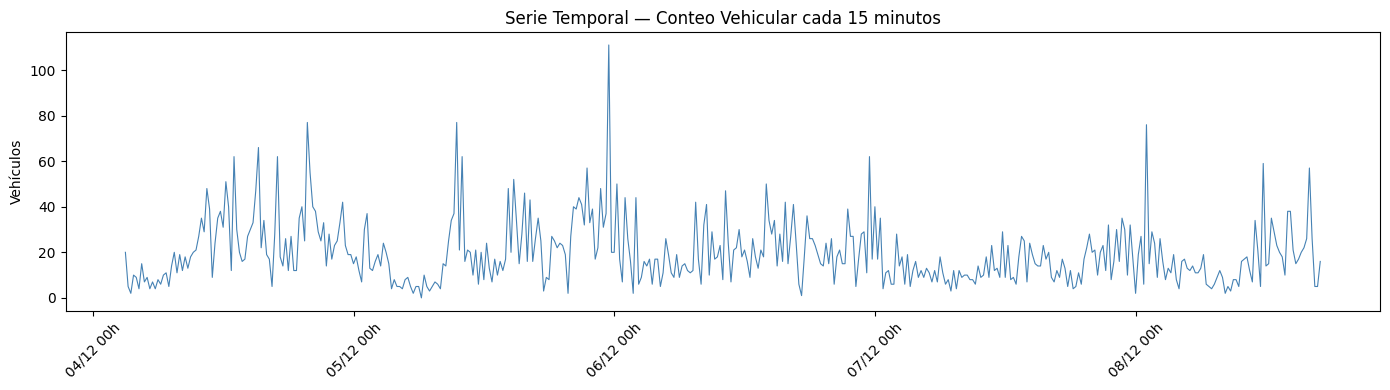

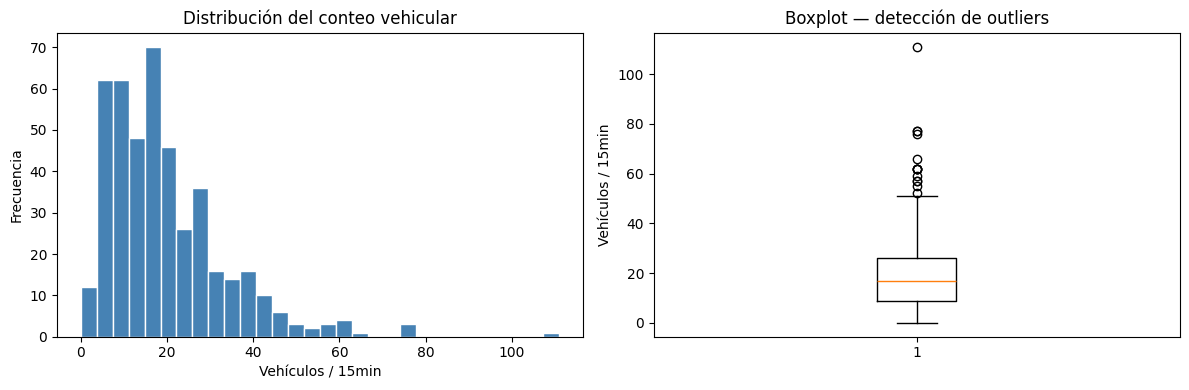

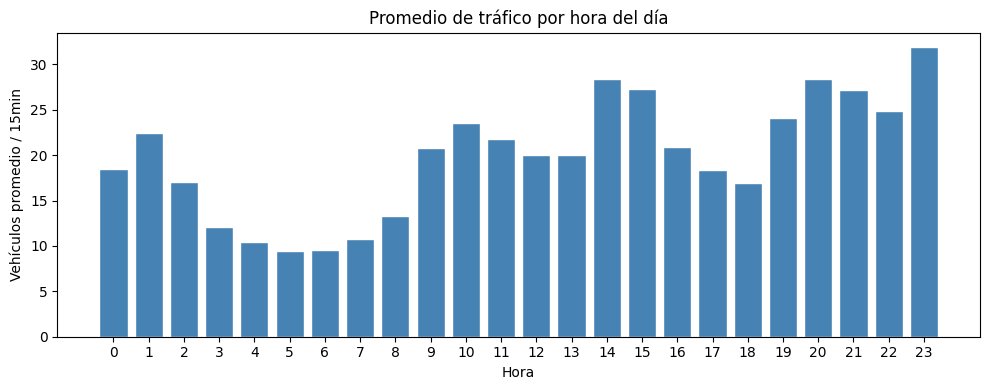

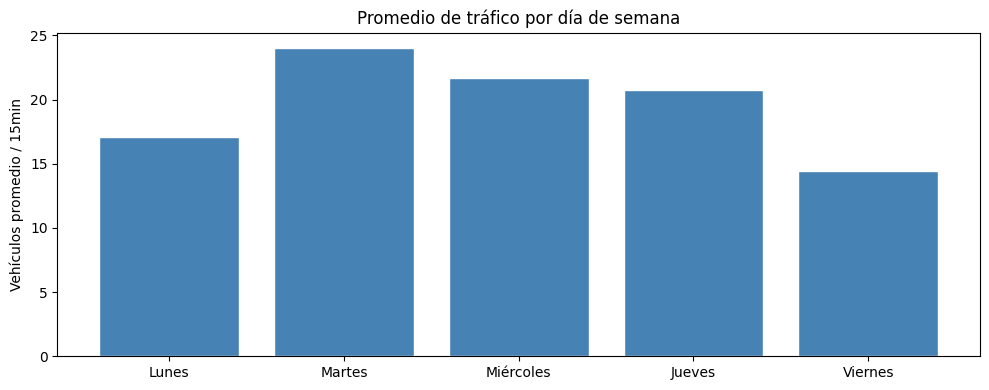

Outliers detectados: 14
count     14.000000
mean      66.785714
std       15.064878
min       52.000000
25%       57.500000
50%       62.000000
75%       73.500000
max      111.000000
Name: body.counting, dtype: float64


In [5]:
# ── Celda 1: Imports ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Celda 2: Carga ───────────────────────────────────────────────
df = pd.read_csv('/content/datos_procesados.csv', index_col='fecha', parse_dates=True)
print(f"Filas: {len(df)}")
print(df.describe())

# ── Celda 3: Serie temporal completa ─────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['body.counting'], linewidth=0.8, color='steelblue')
ax.set_title('Serie Temporal — Conteo Vehicular cada 15 minutos')
ax.set_ylabel('Vehículos')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../content/eda_serie_completa.png', dpi=150)
plt.show()

# ── Celda 4: Distribución de valores ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['body.counting'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del conteo vehicular')
axes[0].set_xlabel('Vehículos / 15min')
axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['body.counting'], vert=True)
axes[1].set_title('Boxplot — detección de outliers')
axes[1].set_ylabel('Vehículos / 15min')

plt.tight_layout()
plt.savefig('../content/eda_distribucion.png', dpi=150)
plt.show()

# ── Celda 5: Patrón por hora del día ─────────────────────────────
df['hora'] = df.index.hour
hourly = df.groupby('hora')['body.counting'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly.index, hourly.values, color='steelblue', edgecolor='white')
ax.set_title('Promedio de tráfico por hora del día')
ax.set_xlabel('Hora')
ax.set_ylabel('Vehículos promedio / 15min')
ax.set_xticks(range(24))
plt.tight_layout()
plt.savefig('../content/eda_patron_hora.png', dpi=150)
plt.show()

# ── Celda 6: Patrón por día de semana ────────────────────────────
dias = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
df['dia_semana'] = df.index.dayofweek
weekly = df.groupby('dia_semana')['body.counting'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dias[:len(weekly)], weekly.values, color='steelblue', edgecolor='white')
ax.set_title('Promedio de tráfico por día de semana')
ax.set_ylabel('Vehículos promedio / 15min')
plt.tight_layout()
plt.savefig('../content/eda_patron_dia.png', dpi=150)
plt.show()

# ── Celda 7: Outliers ────────────────────────────────────────────
Q1 = df['body.counting'].quantile(0.25)
Q3 = df['body.counting'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['body.counting'] < Q1 - 1.5*IQR) | (df['body.counting'] > Q3 + 1.5*IQR)]

print(f"Outliers detectados: {len(outliers)}")
print(outliers['body.counting'].describe())